✅ BUY  2024-06-27 | Price: 10.14
🔴 SELL 2024-08-21 | Price: 11.42
✅ BUY  2025-04-01 | Price: 8.82


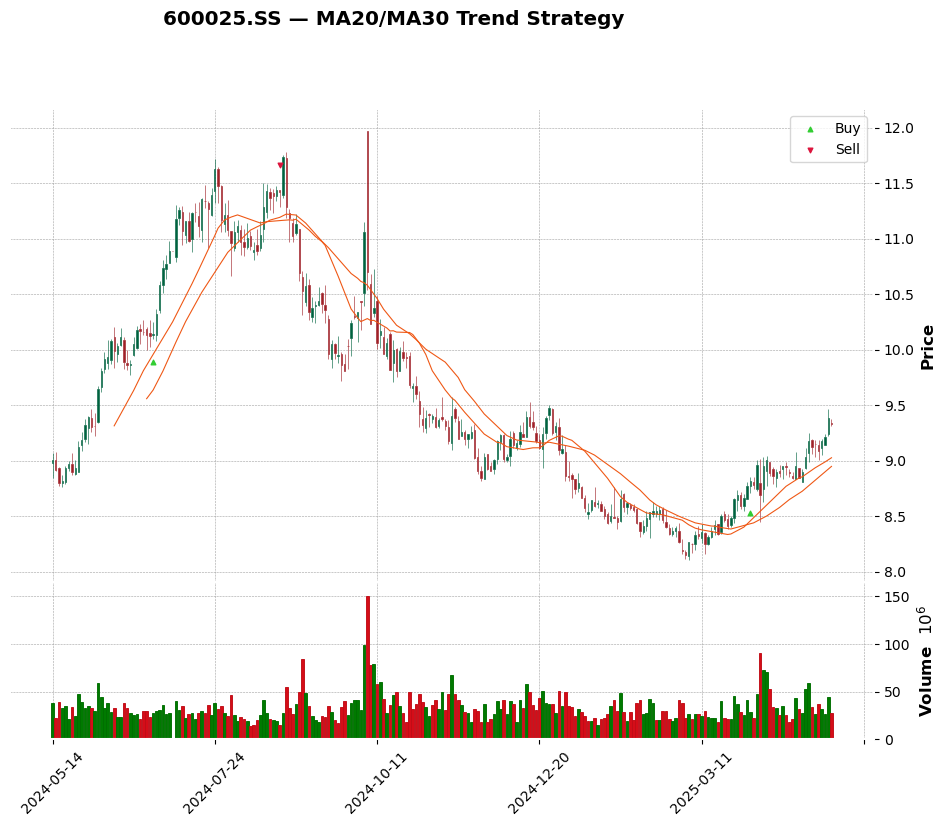


📊 STRATEGY RESULTS — MA20 / MA30 VERSION
Initial Capital:   100,000.00
Final Capital:     118,833.14
Total Return:      18.83%
Max Drawdown:      -6.31%
Sharpe Ratio:      24.48
Total Trades:      2
Buy & Hold Return: 3.55%


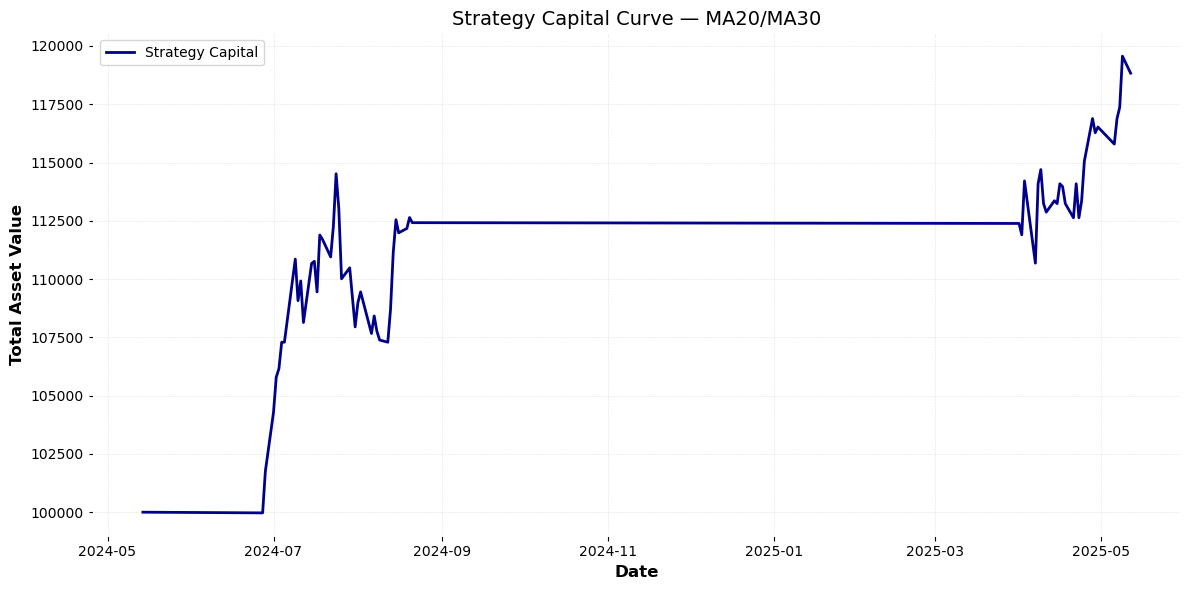

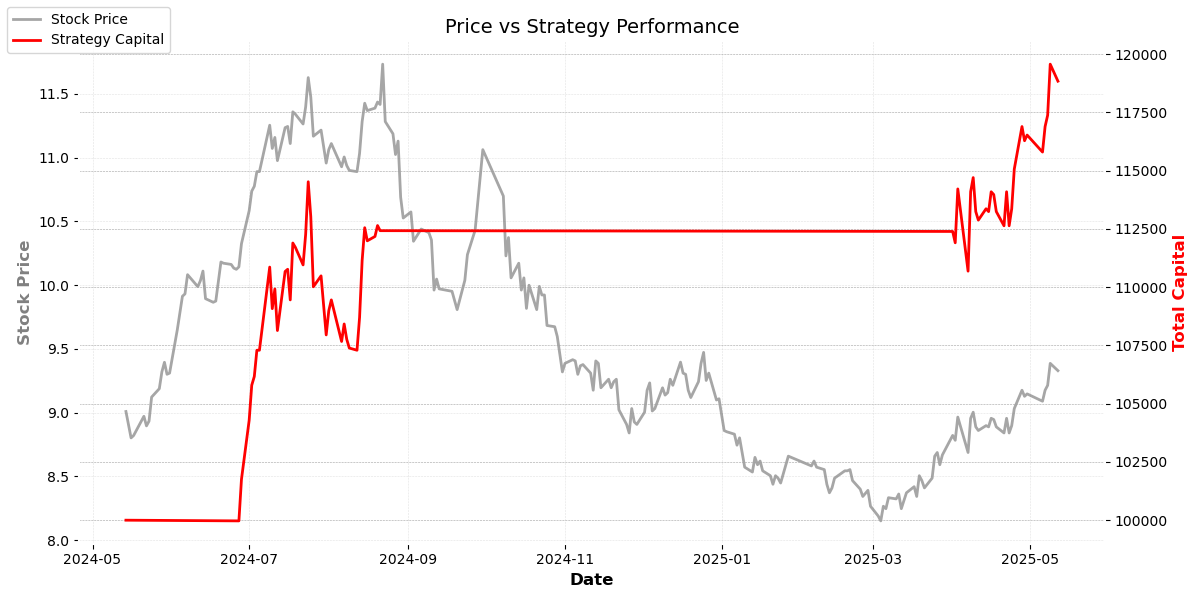

In [3]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
import talib
import mplfinance as mpf
import ffn
import matplotlib.pyplot as plt

# ==============================================
# ⚙️ SETTINGS & THRESHOLDS
# ==============================================
TICKER = "600025.SS"
START_DATE = "2024-05-14"
END_DATE = "2025-05-13"
INITIAL_CAPITAL = 100000
TRANSACTION_FEE = 0.0003

# --- Updated Strategy Rules: MA20 / MA30 ---
MIN_MA_GAP_PCT = 0.2               # MA20 must be at least 0.2% above MA30
MIN_MA30_SLOPE = 0.004             # ✅ MA30 = main trend, slightly lower threshold for slower MA
RSI_BUY_THRESHOLD = 70             # Avoid buying when overbought
RSI_SELL_THRESHOLD = 30            # Avoid selling when deeply oversold

os.makedirs("data", exist_ok=True)

# ==============================================
# 📥 1. GET & PREPARE DATA
# ==============================================
df = yf.download(
    tickers=TICKER,
    start=START_DATE,
    end=END_DATE,
    progress=False
)

df = df.droplevel("Ticker", axis=1).reset_index()
df = df.rename(columns={
    "Date": "trade_date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "vol"
})
df = df[["trade_date", "open", "high", "low", "close", "vol"]]
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# ==============================================
# 📊 2. CALCULATE INDICATORS
# ==============================================
close = df["close"].values

# Updated moving averages
df["MA20"] = talib.SMA(close, timeperiod=20)
df["MA30"] = talib.SMA(close, timeperiod=30)
df["RSI"] = talib.RSI(close, timeperiod=14)

# Trend metrics
df["MA30_slope"] = talib.LINEARREG_SLOPE(df["MA30"], timeperiod=3)  # MAIN TREND = MA30
df["MA_gap_pct"] = (df["MA20"] - df["MA30"]) / df["MA30"] * 100

df["Buy_Signal"] = np.nan
df["Sell_Signal"] = np.nan

# ==============================================
# 🚦 3. BACKTEST LOGIC
# ==============================================
hold = False
pos = 0
cash = INITIAL_CAPITAL
capital_list = []
trade_log = []

for idx, row in df.iterrows():
    price = row["close"]
    ma20 = row["MA20"]
    ma30 = row["MA30"]
    rsi = row["RSI"]
    ma_gap = row["MA_gap_pct"]
    ma30_slope = row["MA30_slope"]
    date = row["trade_date"]

    if pd.isna([ma20, ma30, rsi, ma_gap, ma30_slope]).any():
        capital_list.append(cash + pos * price)
        continue

    # --------------------------
    # BUY: MA20 crosses above MA30 + MA30 clearly rising
    # --------------------------
    if (not hold
        and ma20 > ma30
        and ma_gap > MIN_MA_GAP_PCT
        and ma30_slope > MIN_MA30_SLOPE   # Filter flat/downward main trend
        and rsi < RSI_BUY_THRESHOLD):

        max_shares = int(cash / (price * (1 + TRANSACTION_FEE)))
        pos = (max_shares // 100) * 100  # A-share rule: multiples of 100
        if pos > 0:
            cost = pos * price * (1 + TRANSACTION_FEE)
            cash -= cost
            hold = True
            df.loc[idx, "Buy_Signal"] = row["low"] * 0.98
            trade_log.append(f"BUY | {date.date()} | {price:.2f} | {pos} shares")
            print(f"✅ BUY  {date.date()} | Price: {price:.2f}")

    # --------------------------
    # SELL: MA20 crosses below MA30 OR main trend reverses
    # --------------------------
    elif (hold
          and (ma20 < ma30 or ma30_slope < 0)
          and ma_gap < -MIN_MA_GAP_PCT
          and rsi > RSI_SELL_THRESHOLD):

        proceeds = pos * price * (1 - TRANSACTION_FEE)
        cash += proceeds
        df.loc[idx, "Sell_Signal"] = row["high"] * 1.02
        trade_log.append(f"SELL | {date.date()} | {price:.2f}")
        print(f"🔴 SELL {date.date()} | Price: {price:.2f}")
        pos = 0
        hold = False

    capital_list.append(cash + pos * price)

capital_series = pd.Series(capital_list, index=df["trade_date"])

# ==============================================
# 📈 PLOT & REPORT
# ==============================================
df_plot = df.set_index("trade_date").rename(columns={
    "open": "Open", "high": "High", "low": "Low", "close": "Close", "vol": "Volume"
})

ap_buy = mpf.make_addplot(
    df_plot["Buy_Signal"], type="scatter", marker="^",
    color="limegreen", markersize=11, label="Buy"
)
ap_sell = mpf.make_addplot(
    df_plot["Sell_Signal"], type="scatter", marker="v",
    color="crimson", markersize=11, label="Sell"
)

ap_rsi = [
    mpf.make_addplot(df_plot["RSI"], panel=1, color="purple", ylabel="RSI (14)"),
    mpf.make_addplot([30]*len(df_plot), panel=1, color="green", linestyle="--", width=0.7),
    mpf.make_addplot([70]*len(df_plot), panel=1, color="red", linestyle="--", width=0.7)
]

mpf.plot(
    df_plot,
    type="candle",
    style="charles",
    datetime_format="%Y-%m-%d",
    title=f"{TICKER} — MA20/MA30 Trend Strategy",
    mav=(20, 30),  # Show the new MA pair
    volume=True,
    addplot=[ap_buy, ap_sell] + ap_rsi,
    panel_ratios=(3, 1),
    figsize=(12, 9),
    warn_too_much_data=2000
)

# ==============================================
# 📊 PERFORMANCE SUMMARY
# ==============================================
print("\n" + "="*60)
print("📊 STRATEGY RESULTS — MA20 / MA30 VERSION")
print("="*60)
print(f"Initial Capital:   {INITIAL_CAPITAL:,.2f}")
print(f"Final Capital:     {capital_series.iloc[-1]:,.2f}")
print(f"Total Return:      {ffn.calc_total_return(capital_series):.2%}")
print(f"Max Drawdown:      {ffn.calc_max_drawdown(capital_series):.2%}")
print(f"Sharpe Ratio:      {ffn.calc_sharpe(capital_series):.2f}")
print(f"Total Trades:      {len([t for t in trade_log if 'BUY' in t])}")

bh_return = df["close"].iloc[-1] / df["close"].iloc[0] - 1
print(f"Buy & Hold Return: {bh_return:.2%}")
print("="*60)

# ==============================================
# 📉 CAPITAL CURVE CHARTS
# ==============================================
plt.figure(figsize=(12, 6))
plt.plot(capital_series, label="Strategy Capital", color="darkblue", linewidth=2)
plt.title("Strategy Capital Curve — MA20/MA30", fontsize=14)
plt.ylabel("Total Asset Value")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(df["trade_date"], df["close"], label="Stock Price", color="gray", alpha=0.7)
ax2.plot(capital_series.index, capital_series.values, label="Strategy Capital", color="red", linewidth=2)
ax1.set_xlabel("Date")
ax1.set_ylabel("Stock Price", color="gray")
ax2.set_ylabel("Total Capital", color="red")
ax1.grid(True, alpha=0.3)
fig.legend(loc="upper left")
plt.title("Price vs Strategy Performance", fontsize=14)
plt.tight_layout()
plt.show()